In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
data = pd.read_csv("patients_dataset_unclean.csv")

In [ ]:
data.head(5)

,ID_Patient,Nom_Prénom,Age,Sexe,Poids_kg,Colonne_Inutile,Taille_cm,IMC,Tension_Artérielle,Glycémie_mgdL,Cholestérol_mgdL,Fumeur,Activité_Physique_h,Niveau_Revenu,Diagnostic,Date_Admission,Notes_Médecin,Niveau_Risque
0,P0204,Ines Hamdi,26,NR,56.2,NaN,150.0,25.0,147/92,114.5,254.3,Non,0.6,1,NaN,02/07/2022,NaN,Faible
1,P0267,Bilel Naceur,23,FEMALE,54.3,NaN,168.0,19.2,119/83,111.3,NaN,OUI,6.3,HIGH,RAS,43773,patient diabétique sous insuline,NaN
2,P0153,Ali Gharbi,78,M,115.8,NaN,NaN,NaN,170/100,95.2,223.1,OUI,13.3,2000-5000 DT,Obésite,04/02/2022,Suivi requis,Élevé
3,P0009,Fatma Ksouri,48,F,60.1,NaN,182.0,18.1,104/97,88.9,1000.0,False,2.1h,NaN,hypertension,24/12/2022,Suivi requis,NaN
4,P0234,Ali Ben Ali,60,M,61.2,NaN,152.0,26.5,100/96,87.7,205.7,NaN,4.9,NaN,Diabète type 2,16/07/2021,Patient non coopératif,Modéré


In [ ]:
data.count()

,0
ID_Patient,291
Nom_Prénom,297
Age,292
Sexe,283
Poids_kg,283
Colonne_Inutile,0
Taille_cm,282
IMC,251
Tension_Artérielle,288
Glycémie_mgdL,283


In [ ]:
data.shape

(300, 18)

In [ ]:
data.describe(include='all')

,ID_Patient,Nom_Prénom,Age,Sexe,Poids_kg,Colonne_Inutile,Taille_cm,IMC,Tension_Artérielle,Glycémie_mgdL,Cholestérol_mgdL,Fumeur,Activité_Physique_h,Niveau_Revenu,Diagnostic,Date_Admission,Notes_Médecin,Niveau_Risque
count,291,297,292,283,283,0.0,282.000000,251.000000,288,283,280.000000,260,280,262,278,283,246,267
unique,280,177,84,19,234,NaN,NaN,NaN,283,243,NaN,15,133,15,32,248,12,11
top,P0067,Youssef Chaabane,36,F,110.3,NaN,NaN,NaN,142/83,0,NaN,OUI,13.3,MEDIUM,Obésite,32/13/2021,À revoir dans 3 mois,Faible
freq,2,6,11,72,3,NaN,NaN,NaN,2,7,NaN,25,7,33,16,4,31,98
mean,NaN,NaN,NaN,NaN,NaN,NaN,167.282979,35.951394,NaN,NaN,212.188929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,41.259768,90.848276,NaN,NaN,115.206136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.530000,0.000000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,158.000000,21.450000,NaN,NaN,171.650000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,173.000000,26.900000,NaN,NaN,202.650000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,183.000000,34.050000,NaN,NaN,227.575000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.isnull().any(axis=0)

,0
ID_Patient,True
Nom_Prénom,True
Age,True
Sexe,True
Poids_kg,True
Colonne_Inutile,True
Taille_cm,True
IMC,True
Tension_Artérielle,True
Glycémie_mgdL,True


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Patient           291 non-null    object 
 1   Nom_Prénom           297 non-null    object 
 2   Age                  292 non-null    object 
 3   Sexe                 283 non-null    object 
 4   Poids_kg             283 non-null    object 
 5   Colonne_Inutile      0 non-null      float64
 6   Taille_cm            282 non-null    float64
 7   IMC                  251 non-null    float64
 8   Tension_Artérielle   288 non-null    object 
 9   Glycémie_mgdL        283 non-null    object 
 10  Cholestérol_mgdL     280 non-null    float64
 11  Fumeur               260 non-null    object 
 12  Activité_Physique_h  280 non-null    object 
 13  Niveau_Revenu        262 non-null    object 
 14  Diagnostic           278 non-null    object 
 15  Date_Admission       283 non-null    obj

<Axes: >

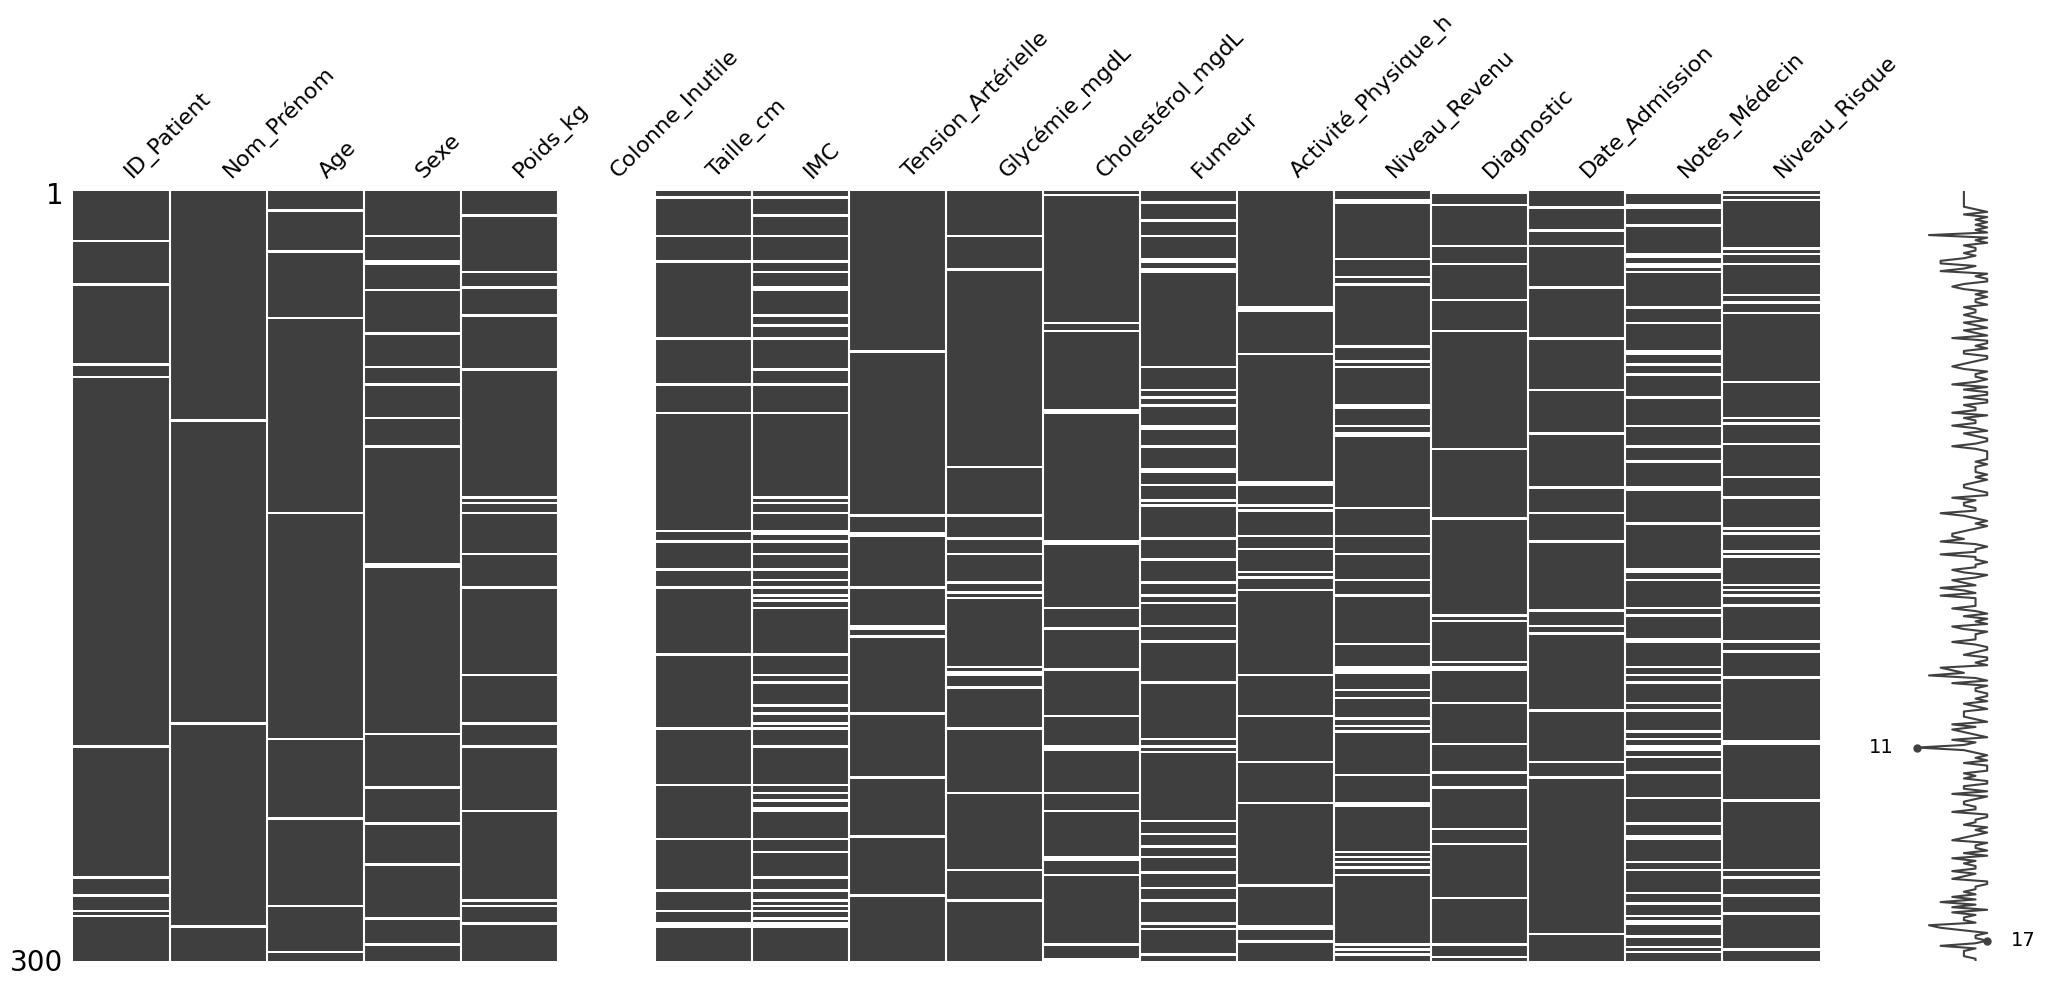

In [ ]:
msno.matrix(data)

In [ ]:
missing_data = pd.DataFrame({
    'Missing Count': data.isnull().sum(),
    'Missing Percentage': (data.isnull().sum() / len(data)) * 100
})
display(missing_data[missing_data['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))

,Missing Count,Missing Percentage
Colonne_Inutile,300,100.000000
Notes_Médecin,54,18.000000
IMC,49,16.333333
Fumeur,40,13.333333
Niveau_Revenu,38,12.666667
Niveau_Risque,33,11.000000
Diagnostic,22,7.333333
Cholestérol_mgdL,20,6.666667
Activité_Physique_h,20,6.666667
Taille_cm,18,6.000000


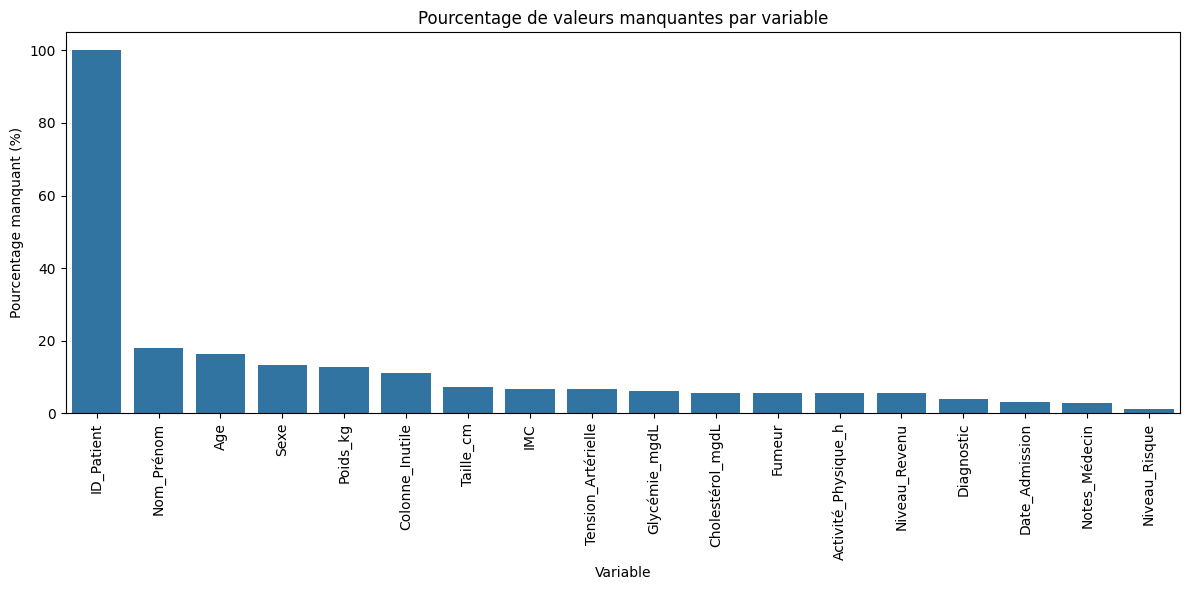

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_data.index, y='Missing Percentage', data=missing_data.sort_values(by='Missing Percentage', ascending=False))
plt.title('Pourcentage de valeurs manquantes par variable')
plt.xlabel('Variable')
plt.ylabel('Pourcentage manquant (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

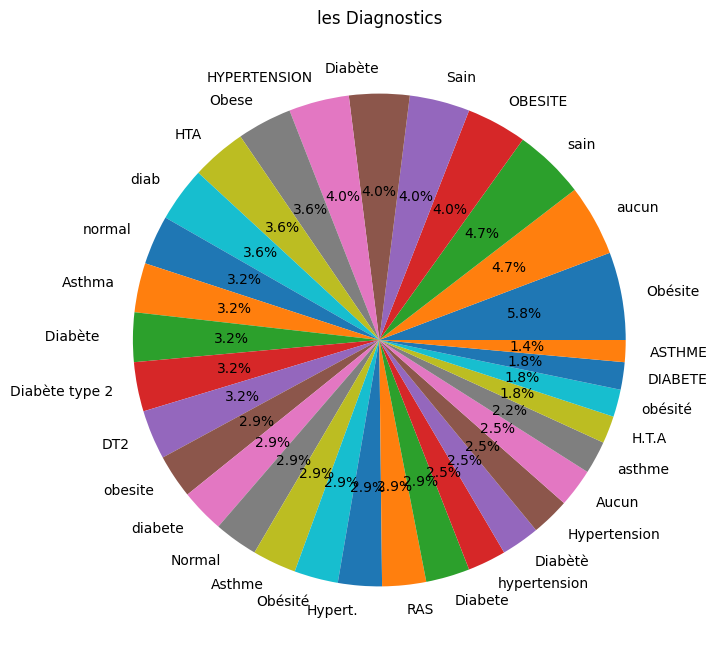

In [ ]:
data['Diagnostic'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title("les Diagnostics")
plt.ylabel('')
plt.show()

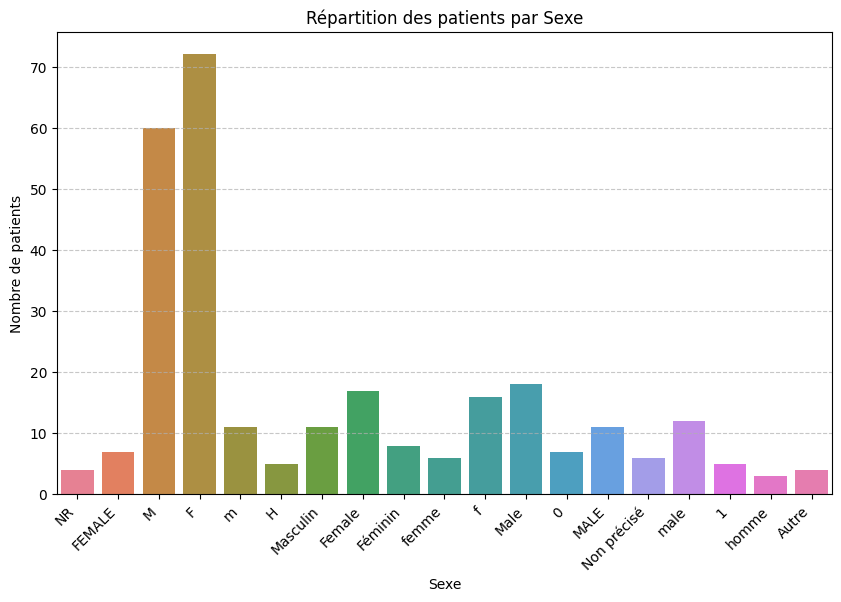

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Sexe', hue='Sexe',legend=False)
plt.title('Répartition des patients par Sexe')
plt.xlabel('Sexe')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

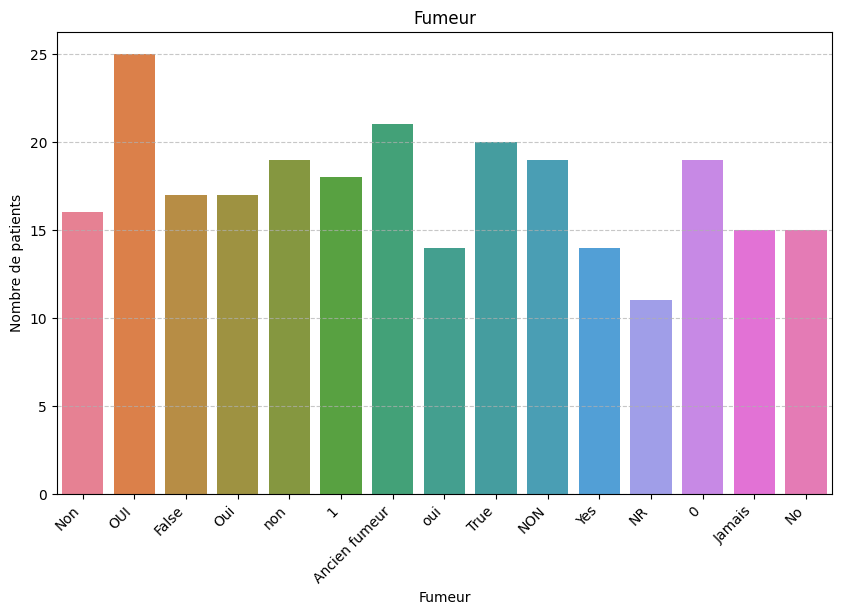

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Fumeur', hue='Fumeur',legend=False)
plt.title('Fumeur')
plt.xlabel('Fumeur')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

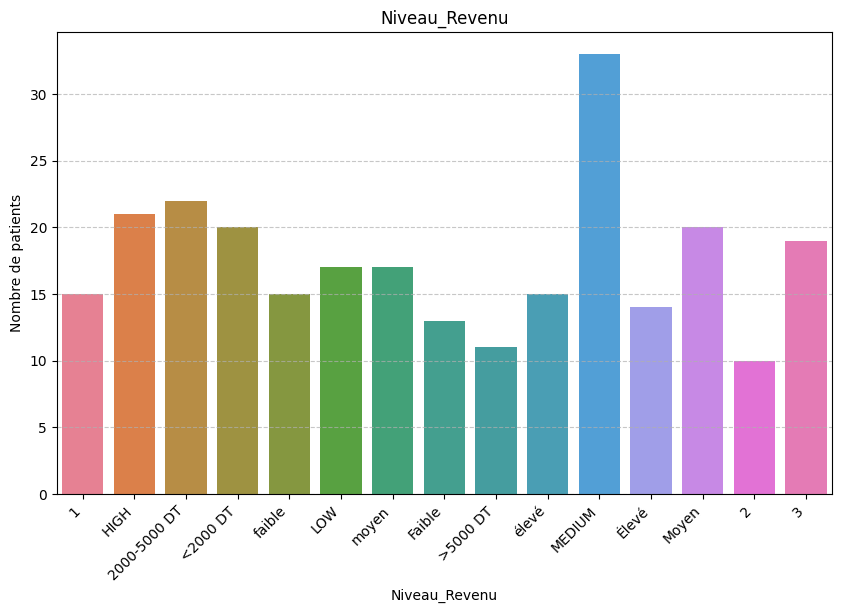

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Niveau_Revenu', hue='Niveau_Revenu',legend=False)
plt.title('Niveau_Revenu')
plt.xlabel('Niveau_Revenu')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

le dataset est très sale et nécessite un nettoyage et une transformation importants avant de pouvoir être utilisé pour des analyses fiables. Il y a des erreurs de saisie, des incohérences de format et un grand volume de données manquantes.

In [ ]:
data['Diagnostic'] = data['Diagnostic'].replace({
    'Obésité': 'Obésité',
    'Obésite': 'Obésité',
    'obésité': 'Obésité',
    'obesite': 'Obésité',
    'OBESITE': 'Obésité',
    'Obese': 'Obésité',
    'obese': 'Obésité',
    'Diabète': 'Diabète',
    'diabète': 'Diabète',
    'Diabete': 'Diabète',
    'Diabèt': 'Diabète',
    'DIABETE': 'Diabète',
    'Diab': 'Diabète',
    'diab': 'Diabète',
    'Diabète type 1': 'Diabète',
    'Diabète type 2': 'Diabète',
    'DT2': 'Diabète',
    'Diabètè': 'Diabète',
    'Hypertension': 'Hypertension',
    'hypertension': 'Hypertension',
    'HYPERTENSION': 'Hypertension',
    'Hypertension artérielle': 'Hypertension',
    'HTA': 'Hypertension',
    'H.T.A': 'Hypertension',
    'Hypert.': 'Hypertension',
    'Asthme': 'Asthme',
    'asthme': 'Asthme',
    'ASTHME': 'Asthme',
    'Asthma': 'Asthme',
    'asthma': 'Asthme',
    'sain': 'Sain',
    'Sain': 'Sain',
    'saine': 'Sain',
    'aucun': 'Sain',
    'Aucun': 'Sain',
    'normal': 'Sain',
    'Normal': 'Sain',
    'RAS': np.nan,
    'Pas de diagnostic': np.nan,
    'aucun diagnostic': np.nan,
    '/': np.nan,
    '': np.nan
})

print("Valeurs uniques de 'Diagnostic' après standardisation:")

Valeurs uniques de 'Diagnostic' après standardisation:


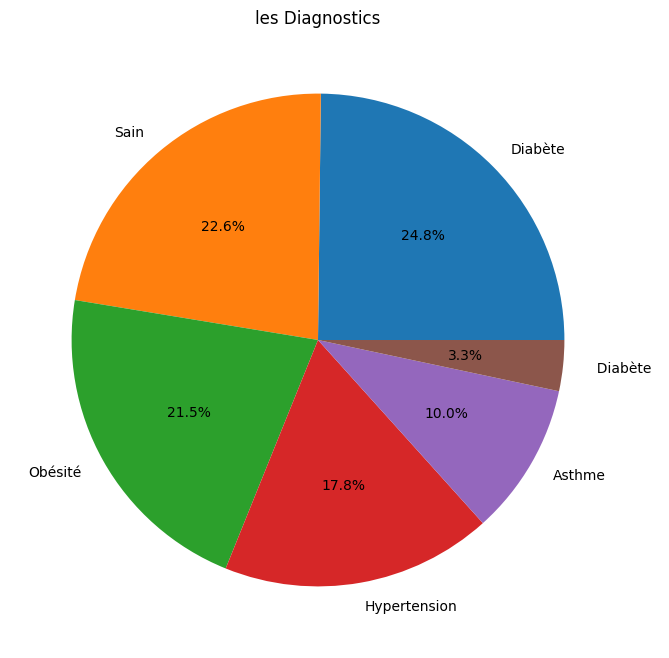

In [ ]:
data['Diagnostic'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title("les Diagnostics")
plt.ylabel('')
plt.show()

In [ ]:
data['Sexe'] = data['Sexe'].replace({
    'M': 'Masculin',
    'm': 'Masculin',
    'MALE': 'Masculin',
    'Male': 'Masculin',
    'male': 'Masculin',
    'Masculin': 'Masculin',
    'masculin': 'Masculin',
    'H': 'Masculin',
    'h': 'Masculin',
    'homme': 'Masculin',
    'Homme': 'Masculin',
    '1': 'Masculin',
    1: 'Masculin',
    'F': 'Féminin',
    'f': 'Féminin',
    'FEMALE': 'Féminin',
    'Female': 'Féminin',
    'female': 'Féminin',
    'Féminin': 'Féminin',
    'féminin': 'Féminin',
    'Feminin': 'Féminin',
    'feminin': 'Féminin',
    'femme': 'Féminin',
    'Femme': 'Féminin',
    '0': 'Féminin',
    0: 'Féminin',
    'NR': np.nan,
    'Non précisé': np.nan,
    'non précisé': np.nan,
    'Autre': np.nan,
    'autre': np.nan,
    '': np.nan
})

print("Valeurs uniques de 'Sexe' après standardisation:")

Valeurs uniques de 'Sexe' après standardisation:


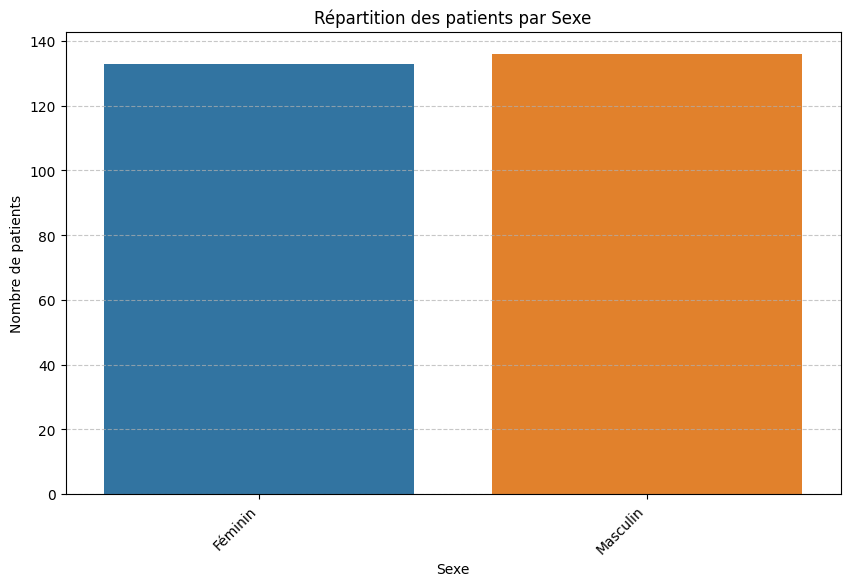

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Sexe', hue='Sexe',legend=False)
plt.title('Répartition des patients par Sexe')
plt.xlabel('Sexe')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
data['Fumeur'] = data['Fumeur'].replace({
    'Oui': 'Oui',
    'oui': 'Oui',
    'OUI': 'Oui',
    'Yes': 'Oui',
    'yes': 'Oui',
    'True': 'Oui',
    True: 'Oui',
    '1': 'Oui',
    1: 'Oui',
    'Non': 'Non',
    'non': 'Non',
    'NON': 'Non',
    'No': 'Non',
    'no': 'Non',
    'False': 'Non',
    False: 'Non',
    '0': 'Non',
    0: 'Non',
    'Jamais': 'Non',
    'jamais': 'Non',
    'Ancien fumeur': 'Ancien fumeur',
    'ancien fumeur': 'Ancien fumeur',
    'Ancien Fumeur': 'Ancien fumeur',
    'Ex-fumeur': 'Ancien fumeur',
    'ex-fumeur': 'Ancien fumeur',
    'NR': np.nan,
    'nr': np.nan,
    '': np.nan
})

print("Valeurs uniques de 'Fumeur' après standardisation:")

Valeurs uniques de 'Fumeur' après standardisation:


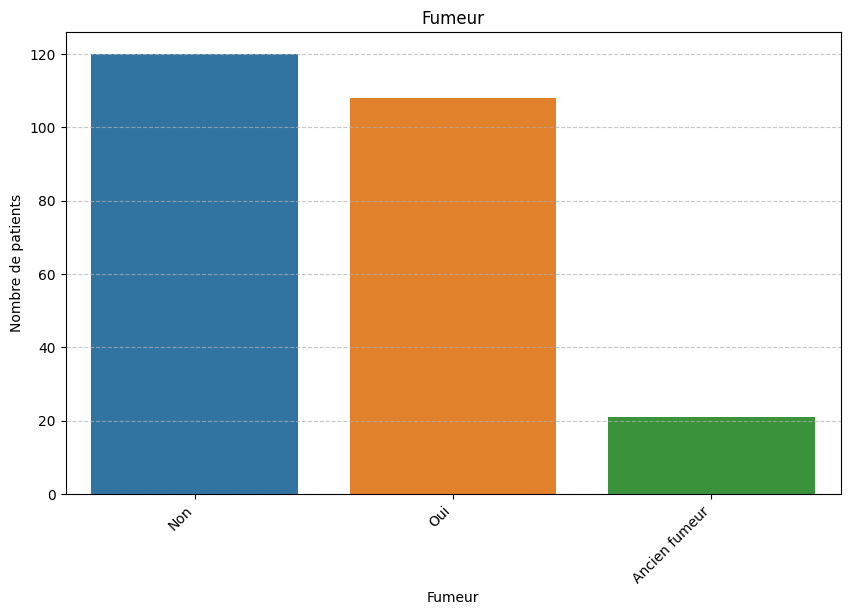

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Fumeur', hue='Fumeur',legend=False)
plt.title('Fumeur')
plt.xlabel('Fumeur')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
data['Niveau_Revenu'] = data['Niveau_Revenu'].replace({
    'faible': 'Faible',
    'Faible': 'Faible',
    'FAIBLE': 'Faible',
    'LOW': 'Faible',
    'low': 'Faible',
    '<2000 DT': 'Faible',
    '1': 'Faible',
    1: 'Faible',
    'moyen': 'Moyen',
    'Moyen': 'Moyen',
    'MOYEN': 'Moyen',
    'MEDIUM': 'Moyen',
    'medium': 'Moyen',
    '2000-5000 DT': 'Moyen',
    '2': 'Moyen',
    2: 'Moyen',
    'élevé': 'Élevé',
    'Élevé': 'Élevé',
    'Elevé': 'Élevé',
    'eleve': 'Élevé',
    'HIGH': 'Élevé',
    'high': 'Élevé',
    '>5000 DT': 'Élevé',
    '3': 'Élevé',
    3: 'Élevé'
})

print("Valeurs uniques de 'Niveau_Revenu' après standardisation:")

Valeurs uniques de 'Niveau_Revenu' après standardisation:


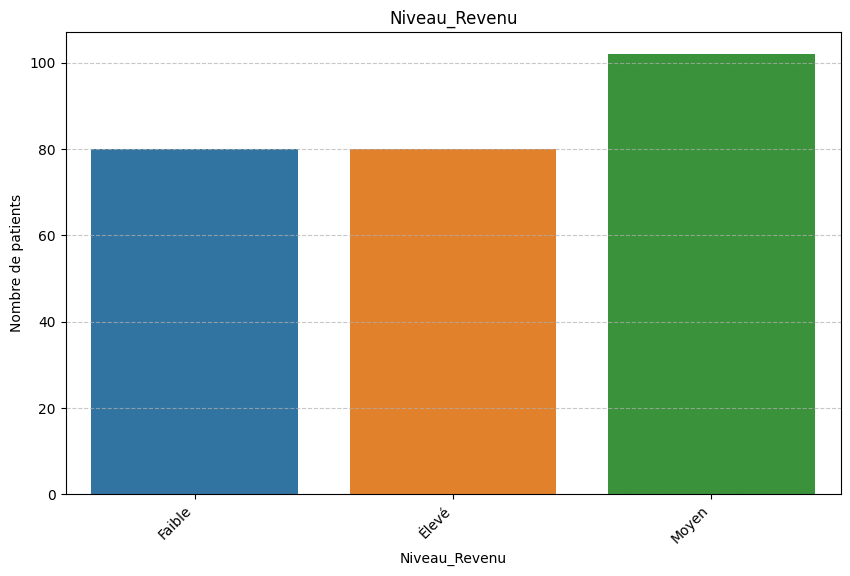

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Niveau_Revenu', hue='Niveau_Revenu',legend=False)
plt.title('Niveau_Revenu')
plt.xlabel('Niveau_Revenu')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



convertir les colonnes numériques

In [ ]:
data['Age'] = pd.to_numeric(data['Age'], errors='coerce')


data['Poids_kg'] = data['Poids_kg'].str.replace(',', '.', regex=True)
data['Poids_kg'] = pd.to_numeric(data['Poids_kg'], errors='coerce')


data['Glycémie_mgdL'] = data['Glycémie_mgdL'].str.replace(',', '.', regex=True)
data['Glycémie_mgdL'] = pd.to_numeric(data['Glycémie_mgdL'], errors='coerce')


data['Activité_Physique_h'] = data['Activité_Physique_h'].str.replace('h', '', regex=False)
data['Activité_Physique_h'] = pd.to_numeric(data['Activité_Physique_h'], errors='coerce')

print("Conversion des types de données numériques effectuée.")

Conversion des types de données numériques effectuée.


convertir la colonne de date

In [ ]:

data['Date_Admission'] = pd.to_datetime(data['Date_Admission'], errors='coerce', dayfirst=False)

print("La colonne 'Date_Admission'convertie en type datetime.")


display(data.info())

La colonne 'Date_Admission'convertie en type datetime.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID_Patient           291 non-null    object        
 1   Nom_Prénom           297 non-null    object        
 2   Age                  282 non-null    float64       
 3   Sexe                 269 non-null    object        
 4   Poids_kg             275 non-null    float64       
 5   Taille_cm            282 non-null    float64       
 6   IMC                  251 non-null    float64       
 7   Tension_Artérielle   288 non-null    object        
 8   Glycémie_mgdL        271 non-null    float64       
 9   Cholestérol_mgdL     280 non-null    float64       
 10  Fumeur               249 non-null    object        
 11  Activité_Physique_h  280 non-null    float64       
 12  Niveau_Revenu        262 non-null    

None

In [ ]:
num_cols = data.select_dtypes(include=np.number).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

In [ ]:
cat_cols = data.select_dtypes(exclude=np.number).columns
data[cat_cols] = data[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

<Axes: >

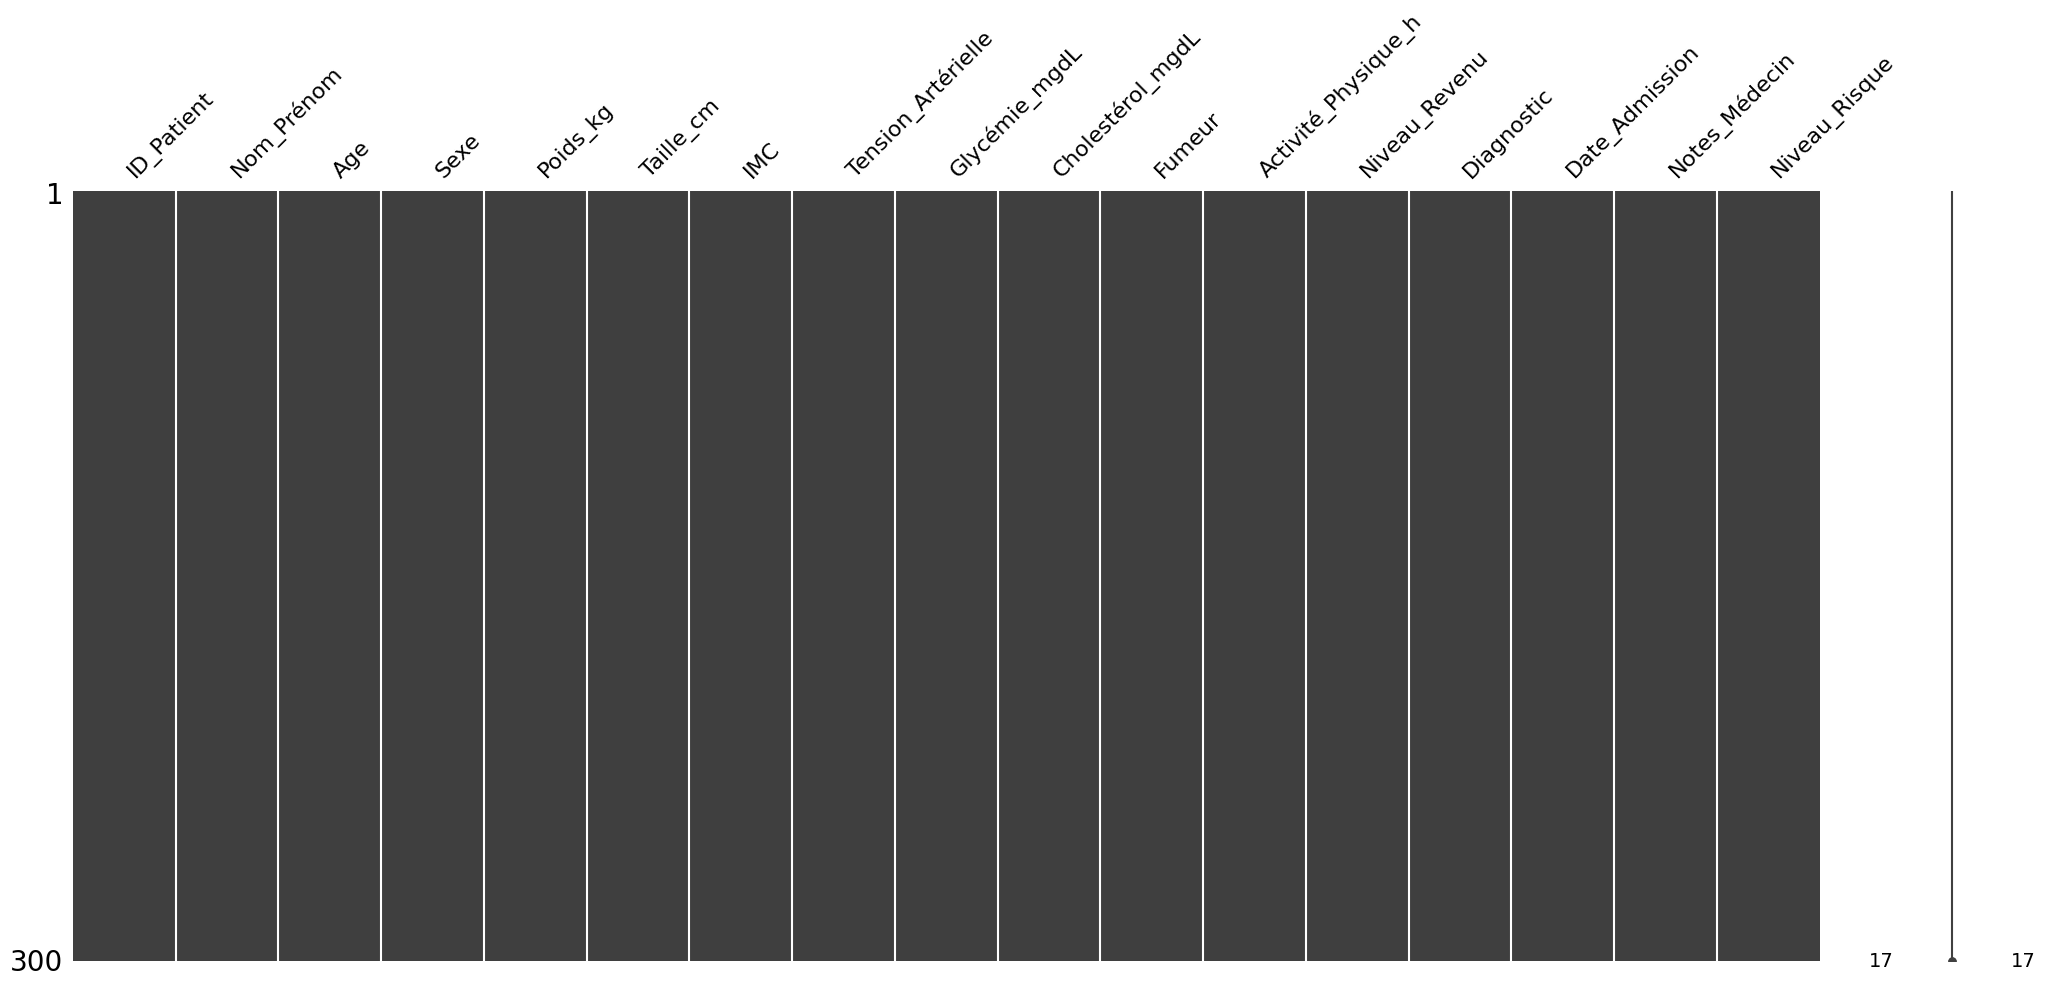

In [ ]:
msno.matrix(data)

In [ ]:
data.head(5)

,ID_Patient,Nom_Prénom,Age,Sexe,Poids_kg,Taille_cm,IMC,Tension_Artérielle,Glycémie_mgdL,Cholestérol_mgdL,Fumeur,Activité_Physique_h,Niveau_Revenu,Diagnostic,Date_Admission,Notes_Médecin,Niveau_Risque
0,P0204,Ines Hamdi,26.0,Masculin,56.2,150.0,25.0,147/92,114.5,254.30,Non,0.6,Faible,Diabète,2022-02-07,À revoir dans 3 mois,Faible
1,P0267,Bilel Naceur,23.0,Féminin,54.3,168.0,19.2,119/83,111.3,202.65,Oui,6.3,Élevé,Diabète,2021-11-09,patient diabétique sous insuline,Faible
2,P0153,Ali Gharbi,78.0,Masculin,115.8,173.0,26.9,170/100,95.2,223.10,Oui,13.3,Moyen,Obésité,2022-04-02,Suivi requis,Élevé
3,P0009,Fatma Ksouri,48.0,Féminin,60.1,182.0,18.1,104/97,88.9,1000.00,Non,2.1,Moyen,Hypertension,2021-11-09,Suivi requis,Faible
4,P0234,Ali Ben Ali,60.0,Masculin,61.2,152.0,26.5,100/96,87.7,205.70,Non,4.9,Moyen,Diabète,2021-11-09,Patient non coopératif,Modéré


In [ ]:
if 'Tension_Artérielle' in data.columns:
    data[['Tension_Systolique', 'Tension_Diastolique']] = data['Tension_Artérielle'].str.split('/', expand=True)

    data['Tension_Systolique'] = pd.to_numeric(data['Tension_Systolique'], errors='coerce')
    data['Tension_Diastolique'] = pd.to_numeric(data['Tension_Diastolique'], errors='coerce')

    data.drop('Tension_Artérielle', axis=1, inplace=True)




In [ ]:
data.head(5)

,ID_Patient,Nom_Prénom,Age,Sexe,Poids_kg,Taille_cm,IMC,Glycémie_mgdL,Cholestérol_mgdL,Fumeur,Activité_Physique_h,Niveau_Revenu,Diagnostic,Date_Admission,Notes_Médecin,Niveau_Risque,Tension_Systolique,Tension_Diastolique
0,P0204,Ines Hamdi,26.0,Masculin,56.2,150.0,25.0,114.5,254.30,Non,0.6,Faible,Diabète,2022-02-07,À revoir dans 3 mois,Faible,147.0,92.0
1,P0267,Bilel Naceur,23.0,Féminin,54.3,168.0,19.2,111.3,202.65,Oui,6.3,Élevé,Diabète,2021-11-09,patient diabétique sous insuline,Faible,119.0,83.0
2,P0153,Ali Gharbi,78.0,Masculin,115.8,173.0,26.9,95.2,223.10,Oui,13.3,Moyen,Obésité,2022-04-02,Suivi requis,Élevé,170.0,100.0
3,P0009,Fatma Ksouri,48.0,Féminin,60.1,182.0,18.1,88.9,1000.00,Non,2.1,Moyen,Hypertension,2021-11-09,Suivi requis,Faible,104.0,97.0
4,P0234,Ali Ben Ali,60.0,Masculin,61.2,152.0,26.5,87.7,205.70,Non,4.9,Moyen,Diabète,2021-11-09,Patient non coopératif,Modéré,100.0,96.0


In [ ]:
for _ in range(5):
    missing_imc_mask = data['IMC'].isnull() & data['Poids_kg'].notnull() & data['Taille_cm'].notnull()
    data.loc[missing_imc_mask, 'IMC'] = data['Poids_kg'] / ((data['Taille_cm'] / 100)**2)

    missing_poids_mask = data['Poids_kg'].isnull() & data['IMC'].notnull() & data['Taille_cm'].notnull()
    data.loc[missing_poids_mask, 'Poids_kg'] = data['IMC'] * ((data['Taille_cm'] / 100)**2)

    missing_taille_mask = data['Taille_cm'].isnull() & data['Poids_kg'].notnull() & data['IMC'].notnull()
    data.loc[missing_taille_mask, 'Taille_cm'] = np.sqrt(data['Poids_kg'] / data['IMC']) * 100

print(data[['Taille_cm', 'Poids_kg', 'IMC']].isnull().sum())


Taille_cm    0
Poids_kg     0
IMC          0
dtype: int64


In [ ]:

columns_to_impute_median = ['Taille_cm', 'Poids_kg', 'IMC']
for col in columns_to_impute_median:
    if data[col].isnull().any():
        median_val = data[col].median()
        data[col].fillna(median_val, inplace=True)
        print(f"Les valeurs manquantes résiduelles dans '{col}' ont été imputées avec la médiane ({median_val}).")
    else:
        print(f"Aucune valeur manquante résiduelle dans '{col}'.")

print("Valeurs manquantes après imputation finale:")
print(data[columns_to_impute_median].isnull().sum())


Aucune valeur manquante résiduelle dans 'Taille_cm'.
Aucune valeur manquante résiduelle dans 'Poids_kg'.
Aucune valeur manquante résiduelle dans 'IMC'.
Valeurs manquantes après imputation finale:
Taille_cm    0
Poids_kg     0
IMC          0
dtype: int64


In [ ]:
print("Valeurs manquantes actuelles après toutes les imputations:")
print(data[['Taille_cm', 'Poids_kg', 'IMC']].isnull().sum())
display(data.head())

Valeurs manquantes actuelles après toutes les imputations:
Taille_cm    0
Poids_kg     0
IMC          0
dtype: int64


,ID_Patient,Nom_Prénom,Age,Sexe,Poids_kg,Taille_cm,IMC,Glycémie_mgdL,Cholestérol_mgdL,Fumeur,Activité_Physique_h,Niveau_Revenu,Diagnostic,Date_Admission,Notes_Médecin,Niveau_Risque,Tension_Systolique,Tension_Diastolique
0,P0204,Ines Hamdi,26.0,Masculin,56.2,150.0,25.0,114.5,254.30,Non,0.6,Faible,Diabète,2022-02-07,À revoir dans 3 mois,Faible,147.0,92.0
1,P0267,Bilel Naceur,23.0,Féminin,54.3,168.0,19.2,111.3,202.65,Oui,6.3,Élevé,Diabète,2021-11-09,patient diabétique sous insuline,Faible,119.0,83.0
2,P0153,Ali Gharbi,78.0,Masculin,115.8,173.0,26.9,95.2,223.10,Oui,13.3,Moyen,Obésité,2022-04-02,Suivi requis,Élevé,170.0,100.0
3,P0009,Fatma Ksouri,48.0,Féminin,60.1,182.0,18.1,88.9,1000.00,Non,2.1,Moyen,Hypertension,2021-11-09,Suivi requis,Faible,104.0,97.0
4,P0234,Ali Ben Ali,60.0,Masculin,61.2,152.0,26.5,87.7,205.70,Non,4.9,Moyen,Diabète,2021-11-09,Patient non coopératif,Modéré,100.0,96.0
